In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%matplotlib inline

In [4]:
Titanic =  pd.read_csv("/kaggle/input/titanic/train.csv",index_col=0)
len(Titanic)
Titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
Titanic['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

Overview of the Data

In [6]:
Titanic.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 11 columns):
Survived    891 non-null int64
Pclass      891 non-null int64
Name        891 non-null object
Sex         891 non-null object
Age         714 non-null float64
SibSp       891 non-null int64
Parch       891 non-null int64
Ticket      891 non-null object
Fare        891 non-null float64
Cabin       204 non-null object
Embarked    889 non-null object
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [7]:
Titanic['Cabin'].fillna(value='Unknown',inplace=True)
Titanic['Embarked'].fillna(value='Unknown',inplace=True)

**Exploratory Data Analysis**

Count Plots of Categorical Variables

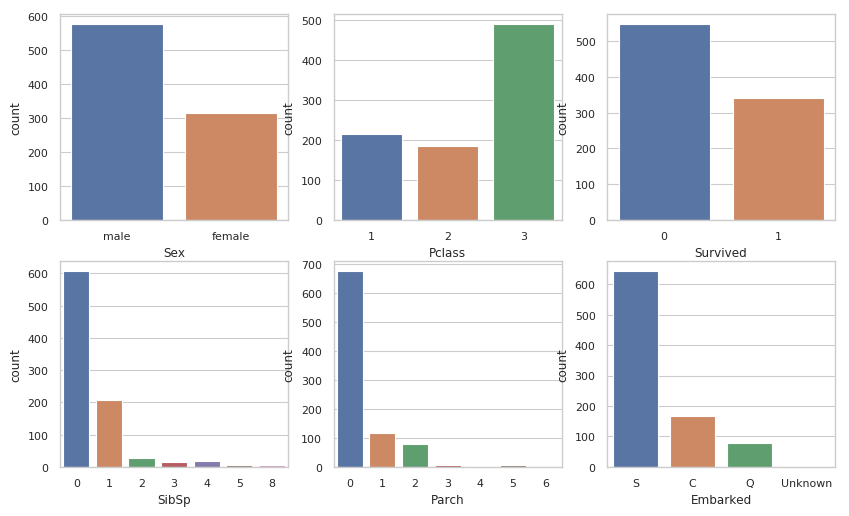

In [8]:
sns.set(style='whitegrid', rc={"grid.linewidth": 0.2})
sns.set_context("paper", font_scale=0.9)
fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(10,6), dpi=100)
# sns.set_context('notebook',font_scale=1)
# sns.set_style('whitegrid')
sns.countplot(x='Sex',data=Titanic,ax=axes[0][0])
sns.countplot(x='Pclass',data=Titanic,ax=axes[0][1])
sns.countplot(x='Survived',data=Titanic,ax=axes[0][2])
sns.countplot(x='SibSp',data=Titanic,ax=axes[1][0])
sns.countplot(x='Parch',data=Titanic,ax=axes[1][1])
sns.countplot(x='Embarked',data=Titanic,ax=axes[1][2])

Distribution plots of continuous variables

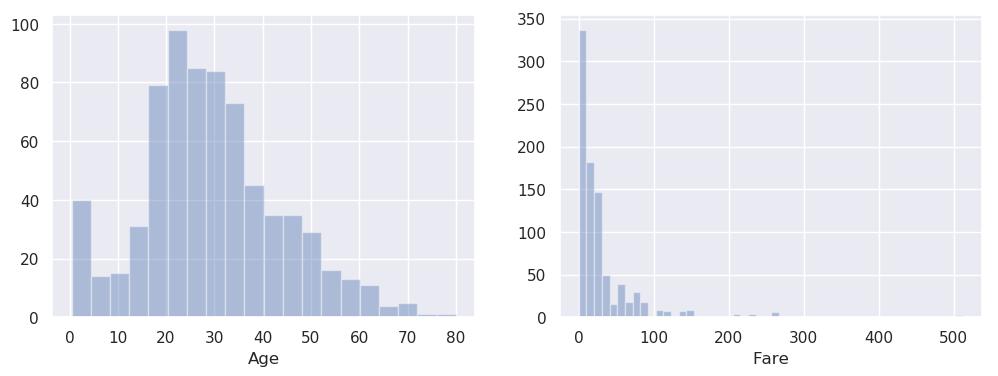

In [9]:
sns.set()
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(12,4), dpi=100)
sns.distplot(Titanic[Titanic['Age'].notnull()]['Age'],ax=axes[0],kde=False)
sns.distplot(Titanic[Titanic['Fare'].notnull()]['Fare'],ax=axes[1],kde=False)

**Analytical Graphs to Check which categorical values are making a difference**

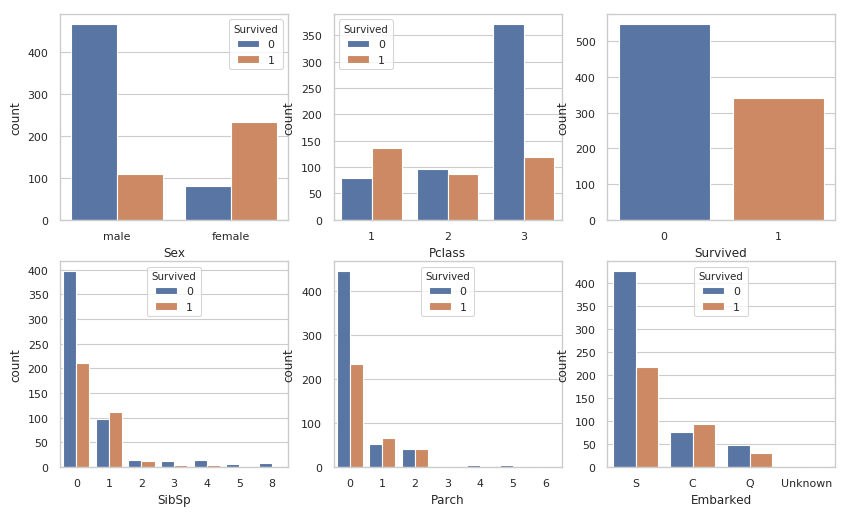

In [10]:
sns.set(style='whitegrid', rc={"grid.linewidth": 0.2})
sns.set_context("paper", font_scale=0.9)
fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(10,6), dpi=100)
# sns.set_context('notebook',font_scale=1)
# sns.set_style('whitegrid')
sns.countplot(x='Sex',data=Titanic,ax=axes[0][0],hue='Survived')
sns.countplot(x='Pclass',data=Titanic,ax=axes[0][1],hue='Survived')
sns.countplot(x='Survived',data=Titanic,ax=axes[0][2])
sns.countplot(x='SibSp',data=Titanic,ax=axes[1][0],hue='Survived')
sns.countplot(x='Parch',data=Titanic,ax=axes[1][1],hue='Survived')
sns.countplot(x='Embarked',data=Titanic,ax=axes[1][2],hue='Survived')

/opt/conda/lib/python3.6/site-packages/seaborn/axisgrid.py:715: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 1500x1500 with 0 Axes>

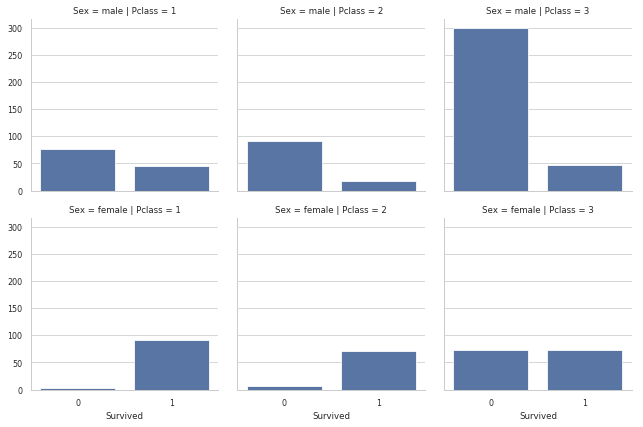

In [11]:
fig=plt.figure(figsize =(15,15),dpi=100)
g = sns.FacetGrid(Titanic, col="Pclass",  row="Sex")
g = g.map(sns.countplot, "Survived")

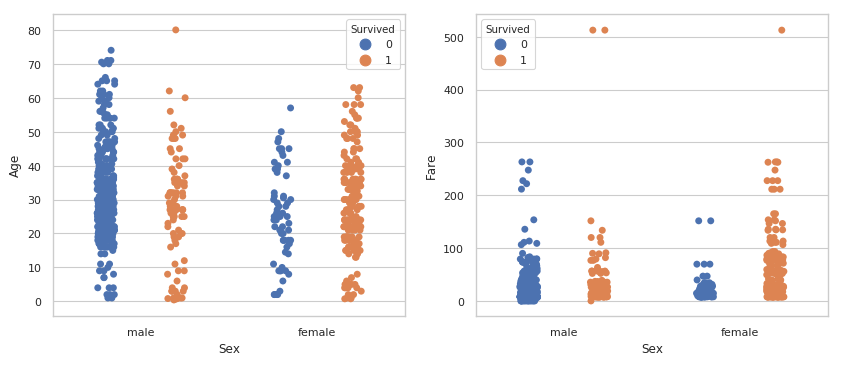

In [12]:
sns.set(style='whitegrid', rc={"grid.linewidth": 0.2})
sns.set_context("paper", font_scale=0.9)
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(10,4), dpi=100)
sns.stripplot(x="Sex", y="Age", data=Titanic,jitter=True,hue='Survived',dodge=True,ax=axes[0])
sns.stripplot(x="Sex", y="Fare", data=Titanic,jitter=True,hue='Survived',dodge=True,ax=axes[1])

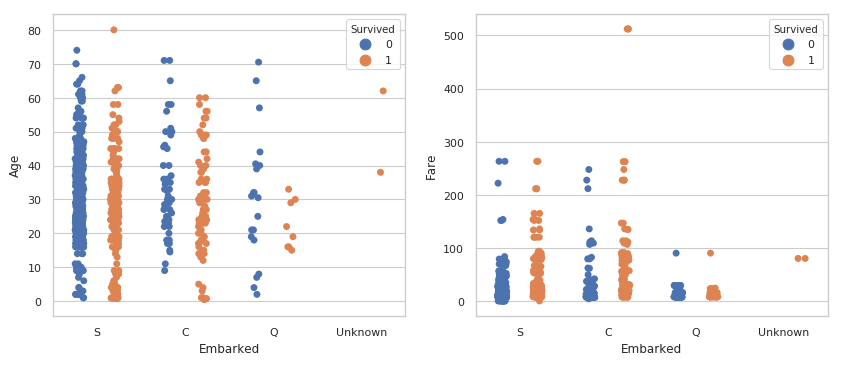

In [13]:
sns.set(style='whitegrid', rc={"grid.linewidth": 0.2})
sns.set_context("paper", font_scale=0.9)
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(10,4), dpi=100)
sns.stripplot(x="Embarked", y="Age", data=Titanic,jitter=True,hue='Survived',dodge=True,ax=axes[0])
sns.stripplot(x="Embarked", y="Fare", data=Titanic,jitter=True,hue='Survived',dodge=True,ax=axes[1])

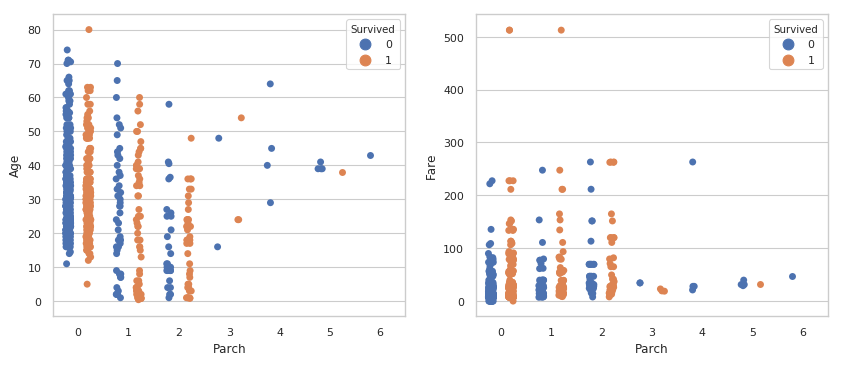

In [14]:
sns.set(style='whitegrid', rc={"grid.linewidth": 0.2})
sns.set_context("paper", font_scale=0.9)
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(10,4), dpi=100)
sns.stripplot(x="Parch", y="Age", data=Titanic,jitter=True,hue='Survived',dodge=True,ax=axes[0])
sns.stripplot(x="Parch", y="Fare", data=Titanic,jitter=True,hue='Survived',dodge=True,ax=axes[1])

Assuming that Age less than 1 is for child below 1 year threfore the data is real , Dropping the missing rows for Embarked and Dropping the columns Name , tiket and cabin

In [15]:
Titanic.drop(['Name','Ticket','Cabin','Age','Fare'],inplace=True,axis=1)
Titanic.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 6 columns):
Survived    891 non-null int64
Pclass      891 non-null int64
Sex         891 non-null object
SibSp       891 non-null int64
Parch       891 non-null int64
Embarked    891 non-null object
dtypes: int64(4), object(2)
memory usage: 88.7+ KB


In [16]:
Test =  pd.read_csv("/kaggle/input/titanic/test.csv",index_col=0)

In [17]:
Test.drop(['Name','Ticket','Cabin','Age','Fare'],inplace=True,axis=1)
Test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 418 entries, 892 to 1309
Data columns (total 5 columns):
Pclass      418 non-null int64
Sex         418 non-null object
SibSp       418 non-null int64
Parch       418 non-null int64
Embarked    418 non-null object
dtypes: int64(3), object(2)
memory usage: 19.6+ KB


We have only two missing values for Embarked column hence dropping that rows of missing values

In [18]:
Titanic.dropna(subset=['Embarked'],inplace=True)

Filling the missing Age by mean for male and female seperately

In [19]:
Titanic[Titanic['Sex']=='male'] = Titanic[Titanic['Sex']=='male'].fillna(Titanic[Titanic['Sex']=='male']['Age'].mean())

KeyError: 'Age'

In [20]:
Titanic[Titanic['Sex']=='female'] = Titanic[Titanic['Sex']=='female'].fillna(Titanic[Titanic['Sex']=='female']['Age'].mean())

KeyError: 'Age'

In [21]:
Titanic.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 6 columns):
Survived    891 non-null int64
Pclass      891 non-null int64
Sex         891 non-null object
SibSp       891 non-null int64
Parch       891 non-null int64
Embarked    891 non-null object
dtypes: int64(4), object(2)
memory usage: 48.7+ KB


Looking for existing corelation through heat map

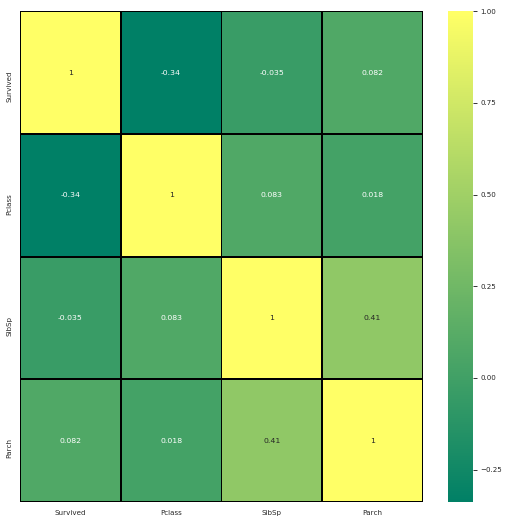

In [22]:
Corr = Titanic.corr()
fig=plt.figure(figsize =(10,10),dpi=65)
sns.heatmap(Corr,cmap='summer',linewidths=1,linecolor='black',annot=True)

/opt/conda/lib/python3.6/site-packages/statsmodels/nonparametric/kde.py:487: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
/opt/conda/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


<Figure size 1500x1500 with 0 Axes>

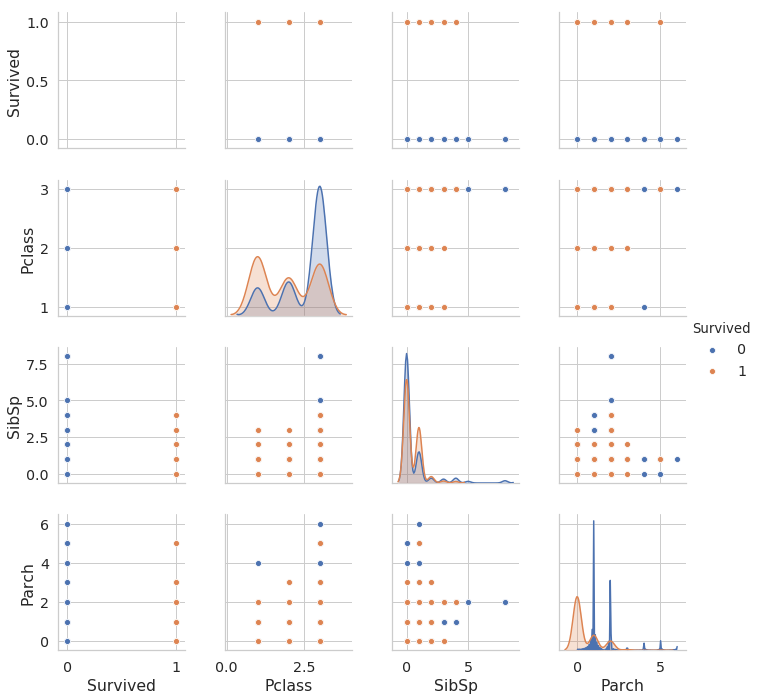

In [23]:
fig =plt.figure(figsize=(15,15),dpi=100)
sns.set_context('notebook',font_scale=1.3)
sns.set_style('whitegrid')
g=sns.pairplot(Titanic,hue='Survived')

**Preprocessing the Data for Model Building******

In [24]:
X = Titanic.iloc[:,1:].values
Y=Titanic.iloc[:,0].values

In [25]:
Xtest = Test.iloc[:,:].values

In [26]:
Xtest

array([[3, 'male', 0, 0, 'Q'],
       [3, 'female', 1, 0, 'S'],
       [2, 'male', 0, 0, 'Q'],
       ...,
       [3, 'male', 0, 0, 'S'],
       [3, 'male', 0, 0, 'S'],
       [3, 'male', 1, 1, 'C']], dtype=object)

In [27]:
from sklearn.preprocessing import LabelEncoder

Label encoding the non numeric columns

In [28]:
LabelCol = [1,4]
for i in LabelCol:
    LabelX = LabelEncoder()
    X[:,i]=LabelX.fit_transform(X[:,i])
    Xtest[:,i]=LabelX.transform(Xtest[:,i])

In [29]:
X

array([[3, 1, 1, 0, 2],
       [1, 0, 1, 0, 0],
       [3, 0, 0, 0, 2],
       ...,
       [3, 0, 1, 2, 2],
       [1, 1, 0, 0, 0],
       [3, 1, 0, 0, 1]], dtype=object)

In [30]:
Xtest

array([[3, 1, 0, 0, 1],
       [3, 0, 1, 0, 2],
       [2, 1, 0, 0, 1],
       ...,
       [3, 1, 0, 0, 2],
       [3, 1, 0, 0, 2],
       [3, 1, 1, 1, 0]], dtype=object)

Building the Model Applying Logistic Rgression only however I have imported other classifier as well

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [33]:
# For ROC curve
def plot_roc_curve(fpr, tpr,col,lab):
    plt.plot(fpr, tpr, color=col, label=lab)
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

In [34]:
X_train,X_test,Y_Train,Y_Test = train_test_split(X,Y,test_size= 0.20)

In [35]:
classifierLogistic = LogisticRegression()
classifierLogistic.fit(X_train, Y_Train)
y_pred_logit = classifierLogistic.predict(X_test)

cm_logit = confusion_matrix(Y_Test, y_pred_logit)
print('Confusion matrix for Logistic',cm_logit)

accuracy_logit = accuracy_score(Y_Test, y_pred_logit)
precision_logit =precision_score(Y_Test, y_pred_logit)
recall_logit =  recall_score(Y_Test, y_pred_logit)
f1_logit = f1_score(Y_Test, y_pred_logit)
print('accuracy_logistic :',accuracy_logit)
print('precision_logistic :',precision_logit)
print('recall_logistic :',recall_logit)
print('f1-score_logistic :',f1_logit)
auc_logit = roc_auc_score(Y_Test, y_pred_logit)
print('AUC_logistic : %.2f' % auc_logit)

Confusion matrix for Logistic [[97 11]
 [17 54]]
accuracy_logistic : 0.8435754189944135
precision_logistic : 0.8307692307692308
recall_logistic : 0.7605633802816901
f1-score_logistic : 0.7941176470588235
AUC_logistic : 0.83


/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


In [36]:
classifierRF = RandomForestClassifier(n_estimators=50,max_depth=10,criterion='entropy')
classifierRF.fit(X, Y)
y_pred_RF = classifierRF.predict(X_test)

cm_RF = confusion_matrix(Y_Test, y_pred_RF)
print('Confusion matrix Random Forest',cm_RF)

accuracy_RF = accuracy_score(Y_Test, y_pred_RF)
precision_RF =precision_score(Y_Test, y_pred_RF)
recall_RF =  recall_score(Y_Test, y_pred_RF)
f1_RF = f1_score(Y_Test, y_pred_RF)
print('accuracy random forest :',accuracy_RF)
print('precision random forest :',precision_RF)
print('recall random forest :',recall_RF)
print('f1-score random forest :',f1_RF)
auc_RF = roc_auc_score(Y_Test, y_pred_RF)
print('AUC: %.2f' % auc_RF)

Confusion matrix Random Forest [[102   6]
 [ 15  56]]
accuracy random forest : 0.88268156424581
precision random forest : 0.9032258064516129
recall random forest : 0.7887323943661971
f1-score random forest : 0.8421052631578947
AUC: 0.87


Text(0, 0.5, 'True Positive Rate')

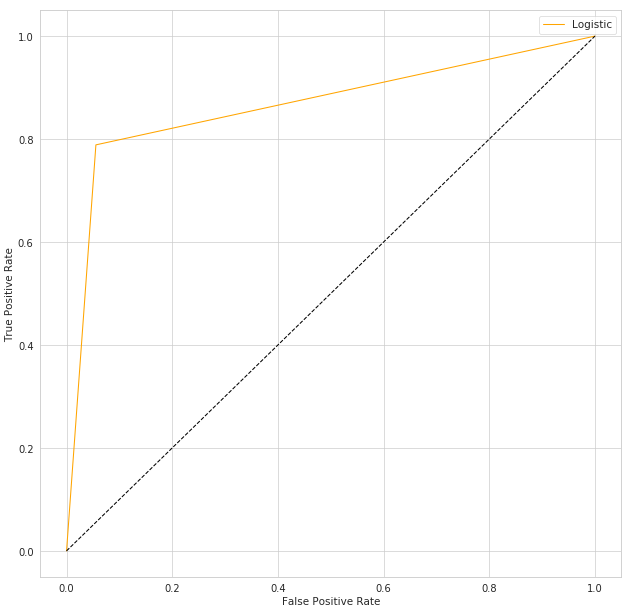

In [37]:
a=[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
b=[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
fig =plt.figure(figsize=(15,15),dpi=50)
fpr, tpr, thresholds = roc_curve(Y_Test,y_pred_RF)
plt.plot(fpr, tpr,color ='orange',label ='Logistic' )
plt.plot(a,b,color='black',linestyle ='dashed')
plt.legend(fontsize=15)
plt.xlabel('False Positive Rate',fontsize=15)
plt.ylabel('True Positive Rate',fontsize=15)

**Applying the model to our test data**

In [38]:
# Test =  pd.read_csv("/kaggle/input/titanic/test.csv",index_col=0)

In [39]:
# Test.head()

In [40]:
# Test.drop(['Name','Ticket','Cabin'],inplace=True,axis=1)
# Test.info()

In [41]:
# Test['Fare'].index[Test['Fare'].apply(np.isnan)]

Filling the Missing value of Fare with the mean of fares for those data which has Embarked as S

In [42]:
# Test['Fare'][1044] =Test[Test['Embarked']=='S']['Fare'].mean()

Filling the Age with mean for male and Female Separately

In [43]:
# Test[Test['Sex']=='male'] = Test[Test['Sex']=='male'].fillna(Test[Test['Sex']=='male']['Age'].mean())
# Test[Test['Sex']=='female'] = Test[Test['Sex']=='female'].fillna(Test[Test['Sex']=='female']['Age'].mean())

In [44]:
# Xtest = Test.iloc[:,:].values

In [45]:
# abelCol = [1,6]
# for i in LabelCol:
#     LabelX = LabelEncoder()
#     Xtest[:,i]=LabelX.fit_transform(Xtest[:,i])

In [46]:
y_pred_test = classifierRF.predict(Xtest)

In [47]:
output = pd.DataFrame({'PassengerId': Test.index, 'Survived': y_pred_test})
output.to_csv('my_submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
